In [58]:
import pandas as pd
import matplotlib.pyplot as plt

**The Emmy Awards: Nominees and Winners:**

Since the first Emmy ceremony in 1949, the television landscape has evolved dramatically, through black-and-white broadcasts, 1950s color TV, 1960s cable expansion, and today’s dominant streaming platforms1. Throughout all these eras, the Emmy Awards, the annual television honors which recognize excellence across categories such as comedy, acting, writing, and technical achievement, have remained the preeminent awards show for the genre.
Among the three organizations overseeing the awards is the Television Academy. The Television Academy has more than 26,000 members, each belonging to one of 31 peer groups representing specific fields such as acting, directing, and writing. For nominations, all active members can vote in program categories, and peer groups vote within their categories of expertise. Before voting begins, contenders must be submitted to appear on the ballot in a specific category, and aspiring nominees must submit an episode of their best work. After nominations are announced, voters are expected to watch episode submissions on the TV Academy’s streaming platform before casting final votes, deciding on one winner per category, such as “Most Outstanding” Awards for Drama, Comedy, Directing, and Writing.
This Emmy nominations dataset reflects the evolution of the television industry by highlighting shifting trends and tastes in television.


In [59]:
!git clone https://github.com/frontiertechinstitute/datasets/blob/main/Emmy%20Awards%20and%20Nominees%20Data/emmys_original.csv


Cloning into 'emmys_original.csv'...
fatal: repository 'https://github.com/frontiertechinstitute/datasets/blob/main/Emmy%20Awards%20and%20Nominees%20Data/emmys_original.csv/' not found


In [60]:
!git clone https://github.com/frontiertechinstitute/datasets


fatal: destination path 'datasets' already exists and is not an empty directory.


In [61]:
df = pd.read_csv("datasets/Emmy Awards and Nominees Data/emmys_original.csv")

df.head(10)

,category,logo,production,type,title,distributor,producer,year,page,page_id
0,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,black-ish: Election Special (Part 2),ABC,ABC,2021,0,1
1,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Bridgerton,Netflix,A Netflix Original Series in association with ...,2021,0,2
2,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Family Guy,FOX,20th Television Animation,2021,0,3
3,Outstanding Character Voice-Over Performance -...,https://www.emmys.com/sites/default/files/styl...,NaN,Nominee,Archer,FX Networks,FX Productions,2021,0,4
4,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Elisabeth Williams, Production Designer",Nominee,The Handmaid's Tale,Hulu,"Hulu, MGM, Daniel Wilson Productions, The Litt...",2021,0,5
5,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Martha Sparrow, Art Director",Nominee,The Handmaid's Tale,Hulu,"Hulu, MGM, Daniel Wilson Productions, The Litt...",2021,0,5
6,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Larry Spittle, Art Director",Nominee,The Handmaid's Tale,Hulu,"Hulu, MGM, Daniel Wilson Productions, The Litt...",2021,0,5
7,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Rob Hepburn, Set Decorator",Nominee,The Handmaid's Tale,Hulu,"Hulu, MGM, Daniel Wilson Productions, The Litt...",2021,0,5
8,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Lester Cohen, Production Designer",Nominee,The Undoing,HBO,"HBO in association with Made Up Stories, Bloss...",2021,0,6
9,Outstanding Production Design For A Narrative ...,https://www.emmys.com/sites/default/files/styl...,"Doug Huszti, Art Director",Nominee,The Undoing,HBO,"HBO in association with Made Up Stories, Bloss...",2021,0,6


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     29678 non-null  object
 1   logo         29678 non-null  object
 2   production   26825 non-null  object
 3   type         29678 non-null  object
 4   title        29678 non-null  object
 5   distributor  29675 non-null  object
 6   producer     29678 non-null  object
 7   year         29678 non-null  int64 
 8   page         29678 non-null  int64 
 9   page_id      29678 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 2.3+ MB


In [63]:
df.isnull().sum()

,0
category,0
logo,0
production,2853
type,0
title,0
distributor,3
producer,0
year,0
page,0
page_id,0


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df["production_code"] = df["production"].fillna("Unknown")
df["distributor"] = df["distributor"].fillna("Unknown")

In [66]:
df.isnull().sum()

,0
category,0
logo,0
production,2853
type,0
title,0
distributor,0
producer,0
year,0
page,0
page_id,0


In [67]:
df["production"] = df["production"].fillna("Unknown")

In [68]:
df.isnull().sum()

,0
category,0
logo,0
production,0
type,0
title,0
distributor,0
producer,0
year,0
page,0
page_id,0


In [69]:
df.columns

Index(['category', 'logo', 'production', 'type', 'title', 'distributor',
       'producer', 'year', 'page', 'page_id', 'production_code'],
      dtype='object')

In [70]:
df = df.drop(columns=["production_code"])

In [71]:
df.columns

Index(['category', 'logo', 'production', 'type', 'title', 'distributor',
       'producer', 'year', 'page', 'page_id'],
      dtype='object')

In [72]:
df["type"].value_counts()

,count
type,
Nominee,23739
Winner,5939


In [73]:
df["distributor"].value_counts().head(10)

,count
distributor,
HBO,4442
NBC,3623
CBS,2963
ABC,2945
Netflix,2144
FOX,1617
FX Networks,1098
Comedy Central,877
PBS,778


In [74]:
df["year"].min(), df["year"].max()

(1957, 2021)

In [75]:
df["year"].value_counts().sort_index()

,count
year,
1957,20
1958,40
1959,20
1961,10
1962,10
...,...
2017,2413
2018,2562
2019,2613


In [76]:
df["category"].nunique()

1821

In [77]:
df["category"].value_counts().head(10)

,count
category,
"Outstanding Technical Direction, Camerawork, Video For A Miniseries, Movie Or A Special - 2007",117
"Outstanding Technical Direction, Camerawork, Video For A Miniseries, Movie Or A Special - 2008",111
Outstanding Drama Series - 2021,109
Outstanding Animated Program - 2019,102
"Outstanding Technical Direction, Camerawork, Video Control For A Miniseries, Movie Or A Special - 2013",101
Outstanding Writing For A Variety Series - 2019,101
"Outstanding Technical Direction, Camerawork, Video Control For A Miniseries, Movie Or A Special - 2009",100
"Outstanding Technical Direction, Camerawork, Video Control For A Miniseries, Movie Or A Special - 2011",100
Outstanding Comedy Series - 2021,99


In [78]:
df["category"].iloc[0]

'Outstanding Character Voice-Over Performance - 2021'

In [79]:
df["title"].nunique()

2022

In [80]:
df["title"].value_counts().head(10)

,count
title,
Saturday Night Live,859
The Voice,582
Dancing With The Stars,538
Game Of Thrones,466
The Amazing Race,425
The Oscars,416
American Idol,276
Top Chef,265
Project Runway,256


In [81]:
df[df["type"] == "Winner"]["distributor"].value_counts().head(10)

,count
distributor,
HBO,1317
NBC,690
CBS,444
ABC,443
Netflix,393
FOX,309
Comedy Central,253
FX Networks,225
PBS,172


In [82]:
df["distributor"].nunique()

200

In [83]:
df[df["distributor"] == "Netflix"]["year"].min()

2013

In [84]:
df["year"].nunique()

61

In [85]:
df["year"].unique()

array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
       2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000,
       1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990, 1989,
       1988, 1987, 1986, 1985, 1984, 1983, 1982, 1981, 1980, 1979, 1978,
       1977, 1976, 1975, 1974, 1973, 1972, 1971, 1970, 1969, 1968, 1967,
       1966, 1962, 1961, 1959, 1958, 1957])

In [86]:
df["distributor"].value_counts(normalize=True).head(10)

,proportion
distributor,
HBO,0.149673
NBC,0.122077
CBS,0.099838
ABC,0.099232
Netflix,0.072242
FOX,0.054485
FX Networks,0.036997
Comedy Central,0.029551
PBS,0.026215


In [87]:
winners_by_year = df[df["type"] == "Winner"]["year"].value_counts().sort_index()
winners_by_year

,count
year,
1957,4
1958,8
1959,4
1961,3
1962,2
...,...
2017,494
2018,436
2019,461


In [88]:
df.describe(include="all")

,category,logo,production,type,title,distributor,producer,year,page,page_id
count,29678,29678,29678,29678,29678,29678,29678,29678.000000,29678.000000,29678.000000
unique,1821,1803,16461,2,2022,200,1507,NaN,NaN,NaN
top,"Outstanding Technical Direction, Camerawork, V...",/sites/all/themes/emmys/img/winners_outsanding...,Unknown,Nominee,Saturday Night Live,HBO,SNL Studios in association with Universal Tele...,NaN,NaN,NaN
freq,117,5555,2853,23739,859,4442,929,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.611025,466.123425,5.497035
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.760282,361.741625,2.877462
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1957.000000,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.000000,188.000000,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,391.000000,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,685.000000,8.000000


In [89]:
df = df.drop(columns=["logo", "page", "page_id"])

In [90]:
df.columns

Index(['category', 'production', 'type', 'title', 'distributor', 'producer',
       'year'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     29678 non-null  object
 1   production   29678 non-null  object
 2   type         29678 non-null  object
 3   title        29678 non-null  object
 4   distributor  29678 non-null  object
 5   producer     29678 non-null  object
 6   year         29678 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 1.6+ MB


In [92]:
winners = df[df["type"] == "Winner"]

In [93]:
df["type"].value_counts()

,count
type,
Nominee,23739
Winner,5939


In [94]:
winners = df[df["type"] == "Winner"]

In [95]:
winners.shape

(5939, 7)

In [96]:
top_distrubutors = winners["distributor"].value_counts().head(10)
top_distrubutors

,count
distributor,
HBO,1317
NBC,690
CBS,444
ABC,443
Netflix,393
FOX,309
Comedy Central,253
FX Networks,225
PBS,172


In [97]:
winners = df[df["type"] == "Winner"]

In [98]:
top_distributors = winners["distributor"].value_counts().head(10)

In [99]:
top_distributors

,count
distributor,
HBO,1317
NBC,690
CBS,444
ABC,443
Netflix,393
FOX,309
Comedy Central,253
FX Networks,225
PBS,172


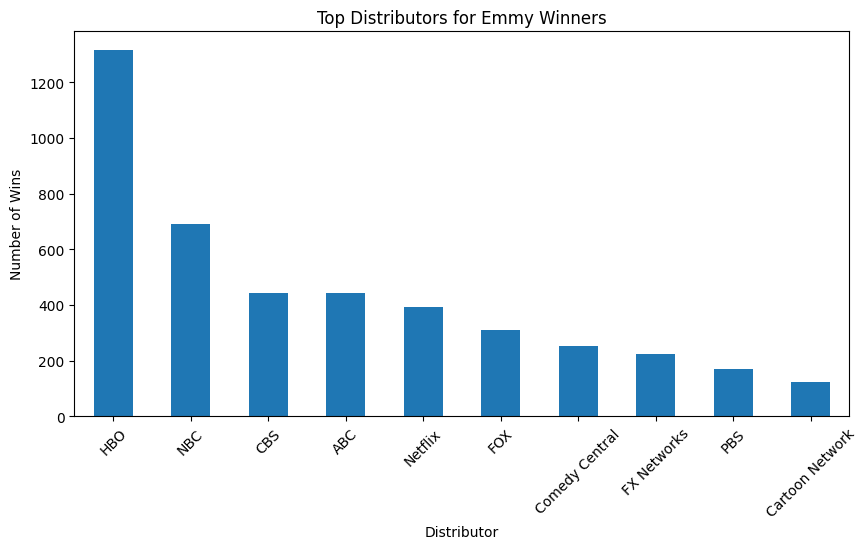

In [100]:
top_distributors.plot(kind="bar", figsize=(10, 5))

plt.title("Top Distributors for Emmy Winners")
plt.xlabel("Distributor")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.show()

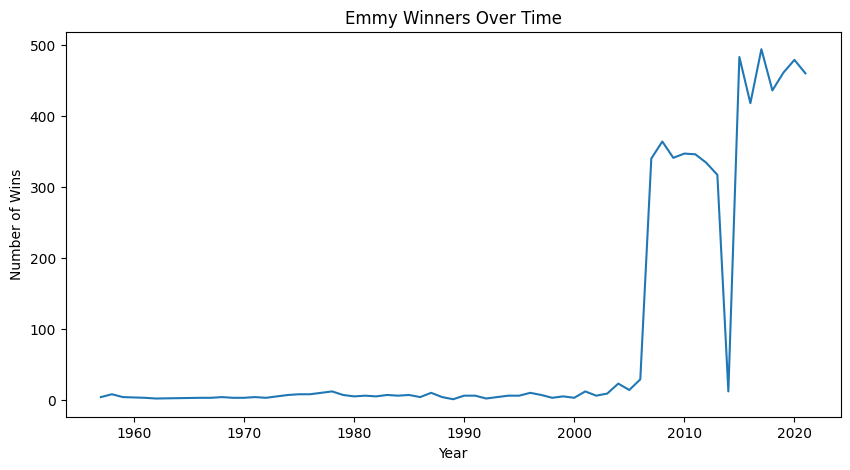

In [101]:
winners_by_year = winners["year"].value_counts().sort_index()

plt.figure(figsize=(10,5))

winners_by_year.plot(kind="line")

plt.title("Emmy Winners Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Wins")

plt.show()

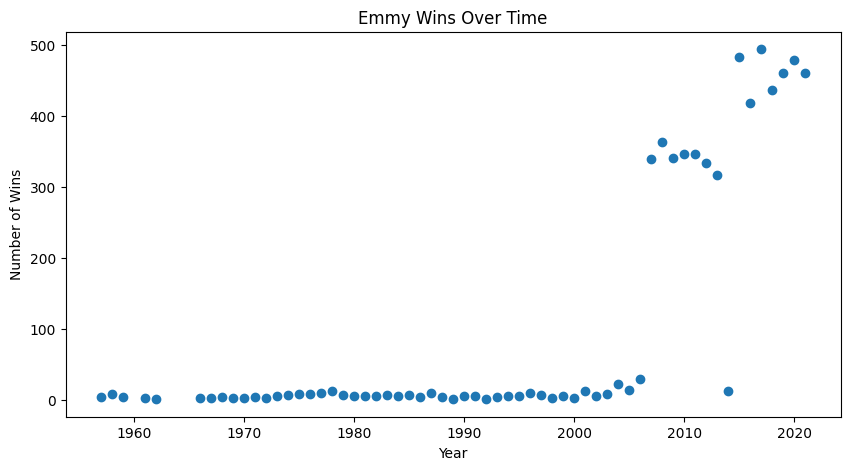

In [102]:
import matplotlib.pyplot as plt

wins_by_year = winners.groupby("year").size()

plt.figure(figsize=(10, 5))

plt.scatter(wins_by_year.index, wins_by_year.values)

plt.title("Emmy Wins Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Wins")

plt.show()

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'HBO'),
  Text(1, 0, 'NBC'),
  Text(2, 0, 'CBS'),
  Text(3, 0, 'ABC'),
  Text(4, 0, 'Netflix'),
  Text(5, 0, 'FOX'),
  Text(6, 0, 'Comedy Central'),
  Text(7, 0, 'FX Networks'),
  Text(8, 0, 'PBS'),
  Text(9, 0, 'Cartoon Network')])

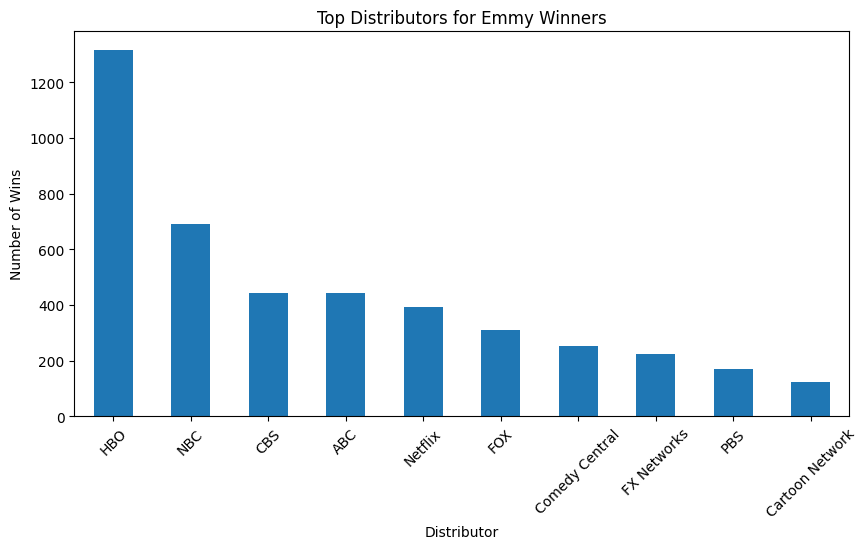

In [103]:
top_distributors = winners["distributor"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_distributors.plot(kind="bar")
plt.title("Top Distributors for Emmy Winners")
plt.xlabel("Distributor")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)

Text(0, 0.5, 'Number of Wins')

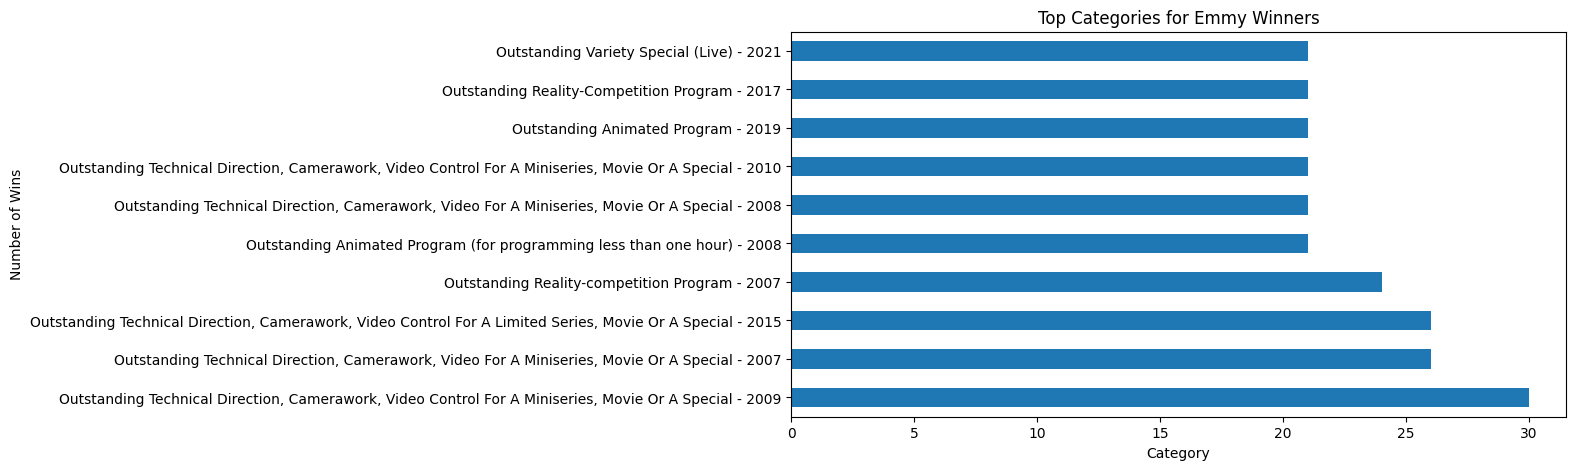

In [104]:
top_distributos = winners["category"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_distributos.plot(kind="barh")
plt.title("Top Categories for Emmy Winners")
plt.xlabel("Category")
plt.ylabel("Number of Wins")

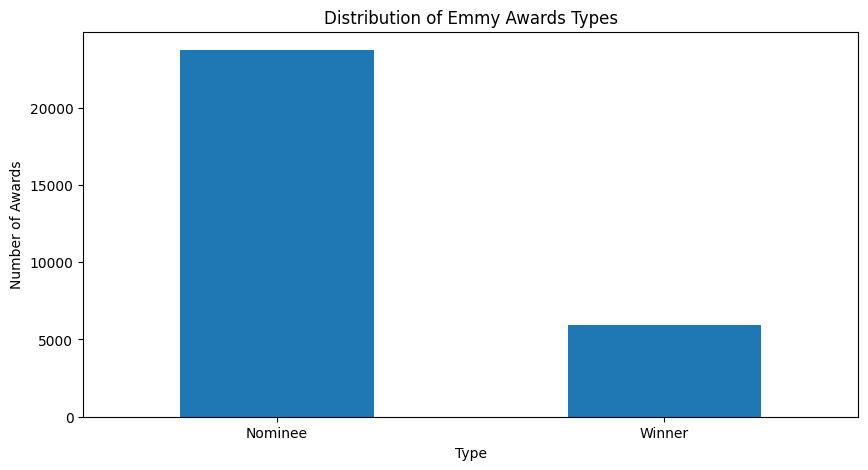

In [105]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(10, 5))
type_counts.plot(kind="bar")
plt.title("Distribution of Emmy Awards Types")
plt.xlabel("Type")
plt.ylabel("Number of Awards")
plt.xticks(rotation=0)
plt.show()

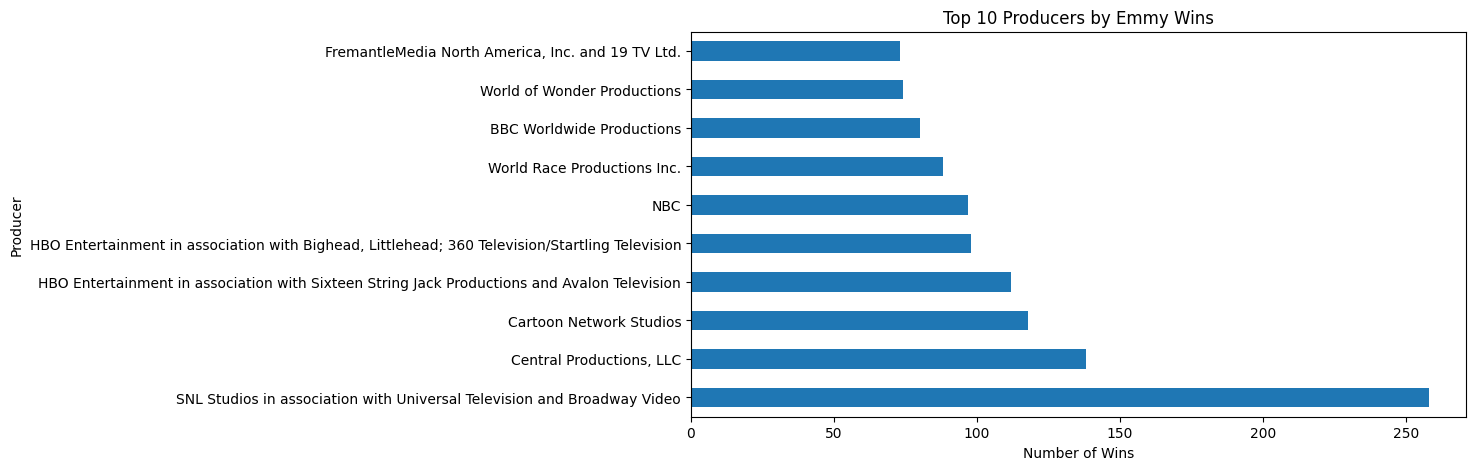

In [106]:
top_producers = winners["producer"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_producers.plot(kind="barh")

plt.title("Top 10 Producers by Emmy Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Producer")

plt.show()